# 04. Synthetic Dataset Exploration

This notebook inspects the 50 synthetic resumes and 20 synthetic job descriptions prepared for Month 1.

## 1. Dataset overview

The data is synthetic and designed only for educational pipeline demonstrations.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

resumes = pd.read_csv(ROOT / "data" / "sample_data" / "resumes.csv")
jds = pd.read_csv(ROOT / "data" / "sample_data" / "job_descriptions.csv")
print("Loaded synthetic datasets")

Loaded synthetic datasets


## 2. Resume dataset dimensions

In [2]:
print("Resume rows and columns:", resumes.shape)

Resume rows and columns: (50, 10)


## 3. JD dataset dimensions

In [3]:
print("JD rows and columns:", jds.shape)

JD rows and columns: (20, 9)


## 4. Schema inspection

In [4]:
print("Resume columns:", resumes.columns.tolist())
print("JD columns:", jds.columns.tolist())
print(resumes.head(2))

Resume columns: ['resume_id', 'candidate_label', 'email', 'phone', 'skills', 'education', 'experience_years', 'job_category', 'resume_text', 'cleaned_text']
JD columns: ['jd_id', 'job_title', 'required_skills', 'preferred_skills', 'experience_required', 'education_required', 'job_category', 'job_description', 'cleaned_text']
  resume_id candidate_label                      email         phone  \
0   RES_001   Candidate_001  candidate001@example.test  000-555-0001   
1   RES_002   Candidate_002  candidate002@example.test  000-555-0002   

       skills             education  experience_years  job_category  \
0  Python;SQL  BSc Computer Science                 2  Data Analyst   
1  Python;NLP      MSc Data Science                 3   ML Engineer   

                                         resume_text  \
0  Synthetic Data Analyst candidate with skills P...   
1  Synthetic ML Engineer candidate with skills Py...   

                                        cleaned_text  
0  synthetic Data 

## 5. Missing-value analysis

In [5]:
missing_summary = pd.DataFrame({"resumes": resumes.isna().sum(), "jds": jds.isna().sum()})
print(missing_summary.fillna(0))

                     resumes  jds
candidate_label          0.0  0.0
cleaned_text             0.0  0.0
education                0.0  0.0
education_required       0.0  0.0
email                    0.0  0.0
experience_required      0.0  0.0
experience_years         0.0  0.0
jd_id                    0.0  0.0
job_category             0.0  0.0
job_description          0.0  0.0
job_title                0.0  0.0
phone                    0.0  0.0
preferred_skills         0.0  0.0
required_skills          0.0  0.0
resume_id                0.0  0.0
resume_text              0.0  0.0
skills                   0.0  0.0


## 6. Duplicate analysis

In [6]:
print("Duplicate resume rows:", resumes.duplicated().sum())
print("Duplicate JD rows:", jds.duplicated().sum())

Duplicate resume rows: 0
Duplicate JD rows: 0


## 7. Job-category distribution

In [7]:
resume_categories = resumes["job_category"].value_counts()
jd_categories = jds["job_category"].value_counts()
print("Resume categories:")
print(resume_categories)
print("JD categories:")
print(jd_categories)

Resume categories:
job_category
Data Analyst          10
ML Engineer           10
NLP Engineer          10
Backend Engineer      10
Analytics Engineer    10
Name: count, dtype: int64
JD categories:
job_category
Data Analyst          4
ML Engineer           4
NLP Engineer          4
Backend Engineer      4
Analytics Engineer    4
Name: count, dtype: int64


## 8. Experience distribution

count    50.000000
mean      4.420000
std       2.304299
min       1.000000
25%       2.250000
50%       4.000000
75%       6.000000
max       8.000000
Name: experience_years, dtype: float64


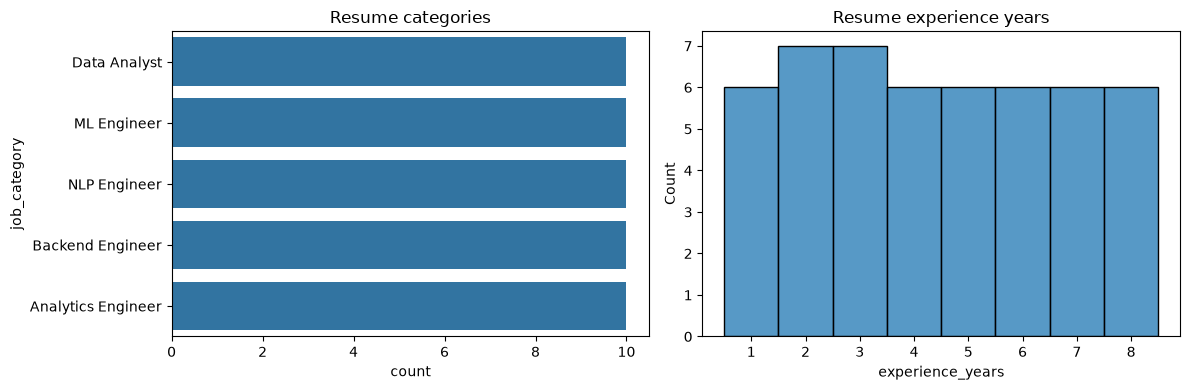

In [8]:
print(resumes["experience_years"].describe())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=resumes, y="job_category", ax=axes[0])
axes[0].set_title("Resume categories")
sns.histplot(data=resumes, x="experience_years", discrete=True, ax=axes[1])
axes[1].set_title("Resume experience years")
plt.tight_layout()

## 9. Skills frequency analysis

skills
Python              20
SQL                 20
NLP                 10
Statistics          10
Pandas              10
Machine Learning    10
Docker              10
AWS                 10
Name: count, dtype: int64


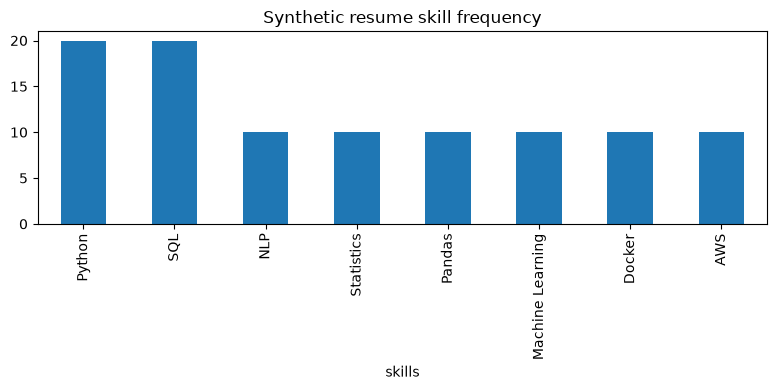

In [9]:
skill_counts = resumes["skills"].str.split(";").explode().str.strip().value_counts()
print(skill_counts)
skill_counts.plot(kind="bar", title="Synthetic resume skill frequency", figsize=(8, 4))
plt.tight_layout()

## 10. JD category analysis

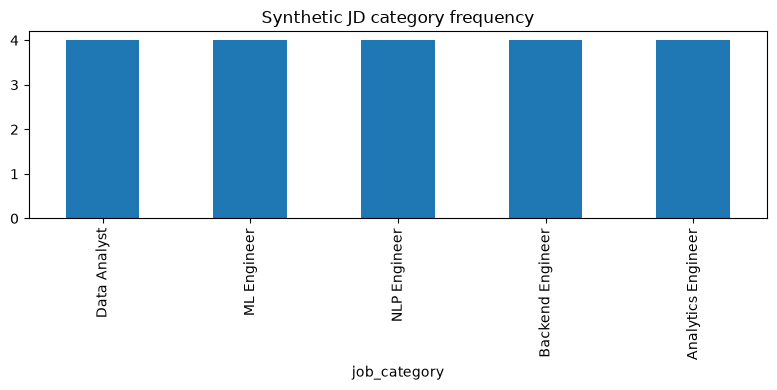

In [10]:
jd_categories.plot(kind="bar", title="Synthetic JD category frequency", figsize=(8, 4))
plt.tight_layout()

## 11. Example cleaned resume

In [11]:
processed_resumes = pd.read_csv(ROOT / "data" / "processed" / "resumes_processed.csv")
print(processed_resumes.loc[0, "cleaned_text"])

synthetic data analyst candidate with skills python sql and 2 years of experience.


## 12. Example cleaned JD

In [12]:
processed_jds = pd.read_csv(ROOT / "data" / "processed" / "job_descriptions_processed.csv")
print(processed_jds.loc[0, "cleaned_text"])

synthetic data analyst position requiring python sql.


## 13. Basic observations

In [13]:
print("Observation: all supplied synthetic rows have values in the canonical fixtures.")
print("Observation: categories and skills provide simple grouping features for future experiments.")

Observation: all supplied synthetic rows have values in the canonical fixtures.
Observation: categories and skills provide simple grouping features for future experiments.


## 14. Dataset limitations

The dataset is small, synthetic, and intentionally simplified. It does not represent real applicant populations, hiring outcomes, protected attributes, or production document variation. It cannot establish model accuracy.

## 15. Privacy and data-safety note

Identifiers use labels such as Candidate_001 and test-domain contact values. No private candidate information or external service is required.

## 16. Key Learning Outcomes

- Load and inspect tabular resume/JD data.
- Check dimensions, schema, missing values, and duplicates.
- Summarize categories, experience, and skills.
- Interpret synthetic exploratory results without overstating them.